<a href="https://colab.research.google.com/github/prabal5ghosh/face_emotion_recognition_private_ensea_data_prabal/blob/main/face_emotion_recognition_prabal_ghosh_2026_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [1]:
import tensorflow as tf
print("GPU devices:", tf.config.list_physical_devices("GPU"))
print("CPU devices:", tf.config.list_physical_devices("CPU"))

GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
CPU devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [2]:

!pip install numpy

# Part A — Imports and Configuration

In [3]:
# ============================================================
# 4) IMPORT LIBRARIES
# ============================================================
import os
import random
from dataclasses import dataclass
from typing import Tuple

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
# from pathlib import Path
# import pandas as pd
# # starting
# # ============================================================
# # ROOT DIRECTORY THAT CONTAINS passage1 ... passage21
# # ============================================================
# ROOT_DIR = Path("/home/raphaeldurso/Bureau/emotion")

# IMG_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# EMOTION_CLASSES = {
#     "angry",
#     "happy",
#     "sad",
#     "neutral",
#     "surprised",
#     "surprise",
#     "fear",
#     "disgust"
# }

# def extract_label_from_filename(filename: str) -> str:
#     name = Path(filename).stem.lower()
#     parts = name.split("_")

#     for part in parts:
#         if part in EMOTION_CLASSES:
#             return part

#     raise ValueError(f"Could not extract emotion label from filename: {filename}")

# rows = []

# for i in range(1, 22):   # passage1 to passage21
#     passage_name = f"passage{i}"
#     learning_dir = ROOT_DIR / passage_name / "emotion" / "frame" / "learning"

#     if not learning_dir.exists():
#         print(f"Warning: folder not found -> {learning_dir}")
#         continue

#     for file_path in learning_dir.rglob("*"):
#         if file_path.is_file() and file_path.suffix.lower() in IMG_EXTENSIONS:
#             label = extract_label_from_filename(file_path.name)

#             rows.append({
#                 "filepath": str(file_path),
#                 "label": label,
#                 "subject_id": passage_name
#             })

# df = pd.DataFrame(rows)

# # normalize label names if needed
# df["label"] = df["label"].replace({
#     "surprised": "surprise"
# })

# print("Total images:", len(df))
# print("\nFirst rows:")
# print(df.head())

# print("\nNumber of subjects/passages:", df["subject_id"].nunique())
# print("\nSubjects:")
# print(sorted(df["subject_id"].unique()))

# print("\nClass distribution:")
# print(df["label"].value_counts())

# print("\nImages per subject:")
# print(df["subject_id"].value_counts().sort_index())

In [5]:
from google.colab import files
uploaded = files.upload()

Saving Emotion.zip to Emotion.zip


In [6]:
!unzip Emotion.zip -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/Emotion/passage10/neutral/c0_17_6_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_17_7_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_17_8_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_17_9_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_0_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_1_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_2_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_3_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_4_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_5_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_6_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_7_neutral_111.png  
  inflating: /content/Emotion/passage10/neutral/c0_1_8_neutral_111.pn

In [ ]:
# from google.colab import drive
# from pathlib import Path
# import os

# drive.mount("/content/drive")

# DRIVE_DATASET = "/content/drive/MyDrive/Emotion"
# LOCAL_DATASET = "/content/Emotion"

# if not os.path.exists(DRIVE_DATASET):
#     raise FileNotFoundError(f"Dataset not found: {DRIVE_DATASET}")

# # remove old copy
# if os.path.exists(LOCAL_DATASET):
#     !rm -rf /content/Emotion

# # copy
# !cp -r "/content/drive/MyDrive/Emotion" "/content/Emotion"

# print("Copy finished.")
# print("Now use:")
# print('DATASET_ROOT = Path("/content/Emotion")')

In [7]:
from pathlib import Path
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# from google.colab import drive
# drive.mount('/content/drive')
DATASET_ROOT = Path("/content/Emotion")

#DATASET_ROOT = Path("/content/drive/MyDrive/Emotion")

In [8]:
print("DATASET ROOT:", DATASET_ROOT)
print("Exists:", DATASET_ROOT.exists())

print("\nFirst level folders:")
for p in DATASET_ROOT.iterdir():
    print(p)

DATASET ROOT: /content/Emotion
Exists: True

First level folders:
/content/Emotion/passage11
/content/Emotion/passage13
/content/Emotion/passage4
/content/Emotion/passage10
/content/Emotion/passage15
/content/Emotion/passage17
/content/Emotion/passage7
/content/Emotion/passage14
/content/Emotion/passage21
/content/Emotion/passage12
/content/Emotion/passage5
/content/Emotion/passage8
/content/Emotion/passage3
/content/Emotion/passage20
/content/Emotion/passage19
/content/Emotion/passage9
/content/Emotion/passage1
/content/Emotion/passage18
/content/Emotion/passage6
/content/Emotion/passage16
/content/Emotion/passage2


In [9]:
rows = []

for subject_dir in sorted(DATASET_ROOT.glob("passage*")):
    if not subject_dir.is_dir():
        continue

    subject_id = subject_dir.name

    for label_dir in sorted(subject_dir.iterdir()):
        if not label_dir.is_dir():
            continue

        label = label_dir.name.lower()

        for img_path in label_dir.glob("*"):
            if img_path.is_file():
                rows.append({
                    "filepath": str(img_path),
                    "label": label,
                    "subject_id": subject_id
                })

df = pd.DataFrame(rows)

print("Total images:", len(df))
print("\nFirst rows:")
print(df.head())

print("\nSubjects:", sorted(df["subject_id"].unique()))
print("\nClass distribution:")
print(df["label"].value_counts().sort_index())

print("\nImages per subject:")
print(df["subject_id"].value_counts().sort_index())

Total images: 5250

First rows:
                                            filepath  label subject_id
0  /content/Emotion/passage1/angry/c0_8_3_angry_0...  angry   passage1
1  /content/Emotion/passage1/angry/c0_22_1_angry_...  angry   passage1
2  /content/Emotion/passage1/angry/c0_22_2_angry_...  angry   passage1
3  /content/Emotion/passage1/angry/c0_13_4_angry_...  angry   passage1
4  /content/Emotion/passage1/angry/c0_8_4_angry_0...  angry   passage1

Subjects: ['passage1', 'passage10', 'passage11', 'passage12', 'passage13', 'passage14', 'passage15', 'passage16', 'passage17', 'passage18', 'passage19', 'passage2', 'passage20', 'passage21', 'passage3', 'passage4', 'passage5', 'passage6', 'passage7', 'passage8', 'passage9']

Class distribution:
label
angry       1050
happy       1050
neutral     1050
sad         1050
surprise    1050
Name: count, dtype: int64

Images per subject:
subject_id
passage1     250
passage10    250
passage11    250
passage12    250
passage13    250
passage14  

(64, 64)
(64, 64)
(64, 64)
(64, 64)
(64, 64)
(64, 64)


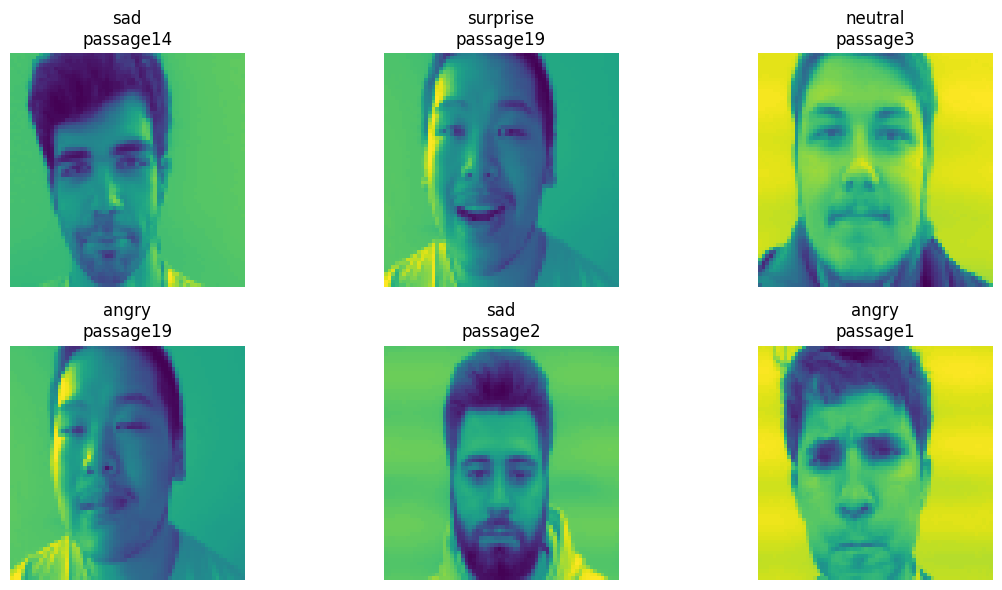

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

sample_df = df.sample(6, random_state=42).reset_index(drop=True)

plt.figure(figsize=(12, 6))
for i in range(len(sample_df)):
    img = Image.open(sample_df.loc[i, "filepath"])
    print(img.size)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f'{sample_df.loc[i, "label"]}\n{sample_df.loc[i, "subject_id"]}')
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
print("Unique labels:", df["label"].unique())
print("Number of unique labels:", df["label"].nunique())
print(df[["filepath", "label", "subject_id"]].head(20))

Unique labels: ['angry' 'happy' 'neutral' 'sad' 'surprise']
Number of unique labels: 5
                                             filepath  label subject_id
0   /content/Emotion/passage1/angry/c0_8_3_angry_0...  angry   passage1
1   /content/Emotion/passage1/angry/c0_22_1_angry_...  angry   passage1
2   /content/Emotion/passage1/angry/c0_22_2_angry_...  angry   passage1
3   /content/Emotion/passage1/angry/c0_13_4_angry_...  angry   passage1
4   /content/Emotion/passage1/angry/c0_8_4_angry_0...  angry   passage1
5   /content/Emotion/passage1/angry/c0_3_2_angry_0...  angry   passage1
6   /content/Emotion/passage1/angry/c0_19_4_angry_...  angry   passage1
7   /content/Emotion/passage1/angry/c0_13_5_angry_...  angry   passage1
8   /content/Emotion/passage1/angry/c0_8_1_angry_0...  angry   passage1
9   /content/Emotion/passage1/angry/c0_8_5_angry_0...  angry   passage1
10  /content/Emotion/passage1/angry/c0_19_8_angry_...  angry   passage1
11  /content/Emotion/passage1/angry/c0_3_7_angry_

In [12]:
df.head(5)

,filepath,label,subject_id
0,/content/Emotion/passage1/angry/c0_8_3_angry_0...,angry,passage1
1,/content/Emotion/passage1/angry/c0_22_1_angry_...,angry,passage1
2,/content/Emotion/passage1/angry/c0_22_2_angry_...,angry,passage1
3,/content/Emotion/passage1/angry/c0_13_4_angry_...,angry,passage1
4,/content/Emotion/passage1/angry/c0_8_4_angry_0...,angry,passage1


In [13]:
# from sklearn.preprocessing import LabelEncoder
# import numpy as np

# # ============================================================
# # LABEL ENCODING
# # ============================================================
# label_encoder = LabelEncoder()
# df["label_id"] = label_encoder.fit_transform(df["label"])

# class_names = list(label_encoder.classes_)
# num_classes = len(class_names)

# print("Classes:", class_names)
# print("Number of classes:", num_classes)

# print(df.head())

In [14]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# ============================================================
# LABEL ENCODING FIRST
# ============================================================
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["label"])

class_names = list(label_encoder.classes_)
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

print("\nLabel mapping:")
for i, class_name in enumerate(class_names):
    print(f"{class_name} -> {i}")

print("\nSample rows:")
print(df[["filepath", "label", "label_id", "subject_id"]].head())

Classes: ['angry', 'happy', 'neutral', 'sad', 'surprise']
Number of classes: 5

Label mapping:
angry -> 0
happy -> 1
neutral -> 2
sad -> 3
surprise -> 4

Sample rows:
                                            filepath  label  label_id  \
0  /content/Emotion/passage1/angry/c0_8_3_angry_0...  angry         0   
1  /content/Emotion/passage1/angry/c0_22_1_angry_...  angry         0   
2  /content/Emotion/passage1/angry/c0_22_2_angry_...  angry         0   
3  /content/Emotion/passage1/angry/c0_13_4_angry_...  angry         0   
4  /content/Emotion/passage1/angry/c0_8_4_angry_0...  angry         0   

  subject_id  
0   passage1  
1   passage1  
2   passage1  
3   passage1  
4   passage1  


In [15]:
# ============================================================
# SUBJECT-WISE SPLIT
# ============================================================
all_subjects = sorted(df["subject_id"].unique())

rng = np.random.default_rng(42)
shuffled_subjects = all_subjects.copy()
rng.shuffle(shuffled_subjects)

train_subjects = shuffled_subjects[:15]
val_subjects   = shuffled_subjects[15:18]
test_subjects  = shuffled_subjects[18:21]

df_train = df[df["subject_id"].isin(train_subjects)].reset_index(drop=True)
df_val   = df[df["subject_id"].isin(val_subjects)].reset_index(drop=True)
df_test  = df[df["subject_id"].isin(test_subjects)].reset_index(drop=True)

print("Train size:", len(df_train))
print("Val size  :", len(df_val))
print("Test size :", len(df_test))

print("\nTrain class distribution:")
print(df_train["label"].value_counts())

print("\nValidation class distribution:")
print(df_val["label"].value_counts())

print("\nTest class distribution:")
print(df_test["label"].value_counts())

Train size: 3750
Val size  : 750
Test size : 750

Train class distribution:
label
angry       750
happy       750
neutral     750
sad         750
surprise    750
Name: count, dtype: int64

Validation class distribution:
label
angry       150
happy       150
neutral     150
sad         150
surprise    150
Name: count, dtype: int64

Test class distribution:
label
angry       150
happy       150
neutral     150
sad         150
surprise    150
Name: count, dtype: int64


In [16]:
# ============================================================
# CHOOSE SPLIT TYPE
# ============================================================
from sklearn.model_selection import train_test_split
import numpy as np

split_type = "random"   # "random" or "subject"

if split_type == "subject":
    all_subjects = sorted(df["subject_id"].unique())

    rng = np.random.default_rng(42)
    shuffled_subjects = all_subjects.copy()
    rng.shuffle(shuffled_subjects)

    train_subjects = shuffled_subjects[:15]
    val_subjects   = shuffled_subjects[15:18]
    test_subjects  = shuffled_subjects[18:21]

    df_train = df[df["subject_id"].isin(train_subjects)].reset_index(drop=True)
    df_val   = df[df["subject_id"].isin(val_subjects)].reset_index(drop=True)
    df_test  = df[df["subject_id"].isin(test_subjects)].reset_index(drop=True)

elif split_type == "random":
    df_train, df_temp = train_test_split(
        df,
        test_size=0.30,
        stratify=df["label"],
        random_state=42,
        shuffle=True
    )

    df_val, df_test = train_test_split(
        df_temp,
        test_size=0.50,
        stratify=df_temp["label"],
        random_state=42,
        shuffle=True
    )

    df_train = df_train.reset_index(drop=True)
    df_val   = df_val.reset_index(drop=True)
    df_test  = df_test.reset_index(drop=True)

else:
    raise ValueError("split_type must be either 'random' or 'subject'")

print("Split type:", split_type)
print("Train size:", len(df_train))
print("Val size  :", len(df_val))
print("Test size :", len(df_test))

print("\nTrain class distribution:")
print(df_train["label"].value_counts())

print("\nValidation class distribution:")
print(df_val["label"].value_counts())

print("\nTest class distribution:")
print(df_test["label"].value_counts())

print("\nTrain subjects:", df_train["subject_id"].nunique())
print("Val subjects  :", df_val["subject_id"].nunique())
print("Test subjects :", df_test["subject_id"].nunique())

Split type: random
Train size: 3675
Val size  : 787
Test size : 788

Train class distribution:
label
neutral     735
surprise    735
happy       735
angry       735
sad         735
Name: count, dtype: int64

Validation class distribution:
label
happy       158
surprise    158
angry       157
sad         157
neutral     157
Name: count, dtype: int64

Test class distribution:
label
sad         158
neutral     158
angry       158
happy       157
surprise    157
Name: count, dtype: int64

Train subjects: 21
Val subjects  : 21
Test subjects : 21


The private dataset was divided using a subject-independent protocol. Fifteen passages were used for training, three for validation, and three for testing. Each split preserved a perfectly balanced distribution across the five emotion classes, with 750 training images, 150 validation images, and 150 test images per class.

#### new

In [17]:
# ============================================================
# IMAGE LOADING + TF.DATA PREPARATION
# ============================================================
from dataclasses import dataclass
from typing import Tuple
import tensorflow as tf
import matplotlib.pyplot as plt

@dataclass
class Config:
    # image settings
    image_size: Tuple[int, int] = (64, 64)
    channels: int = 1
    use_grayscale: bool = True

    # dataset settings
    batch_size: int = 32
    random_state: int = 42

    # model settings
    latent_dim: int = 64
    learning_rate: float = 1e-3
    epochs: int = 80
    l2_reg: float = 1e-4
    dropout_rate: float = 0.15

CFG = Config()
AUTOTUNE = tf.data.AUTOTUNE


def load_and_preprocess_image(path: tf.Tensor, label: tf.Tensor):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=CFG.channels, expand_animations=False)
    image = tf.image.resize(image, CFG.image_size)

    image = tf.cast(image, tf.float32) / 255.0

    if CFG.use_grayscale and CFG.channels == 1:
        image.set_shape((*CFG.image_size, 1))
    else:
        image.set_shape((*CFG.image_size, CFG.channels))

    return image, label


data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomTranslation(height_factor=0.05, width_factor=0.05),
], name="data_augmentation")


def make_dataset(df_split, training=False):
    paths = df_split["filepath"].values
    labels = df_split["label_id"].values.astype("int32")

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    if training:
        ds = ds.shuffle(
            buffer_size=len(df_split),
            seed=CFG.random_state,
            reshuffle_each_iteration=True
        )

    ds = ds.map(load_and_preprocess_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(CFG.batch_size).prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(df_train, training=True)
val_ds   = make_dataset(df_val, training=False)
test_ds  = make_dataset(df_test, training=False)

print("train_ds:", train_ds)
print("val_ds  :", val_ds)
print("test_ds :", test_ds)
print("latent_dim:", CFG.latent_dim)
print("learning_rate:", CFG.learning_rate)

train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
val_ds  : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
test_ds : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 64, 64, 1), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
latent_dim: 64
learning_rate: 0.001


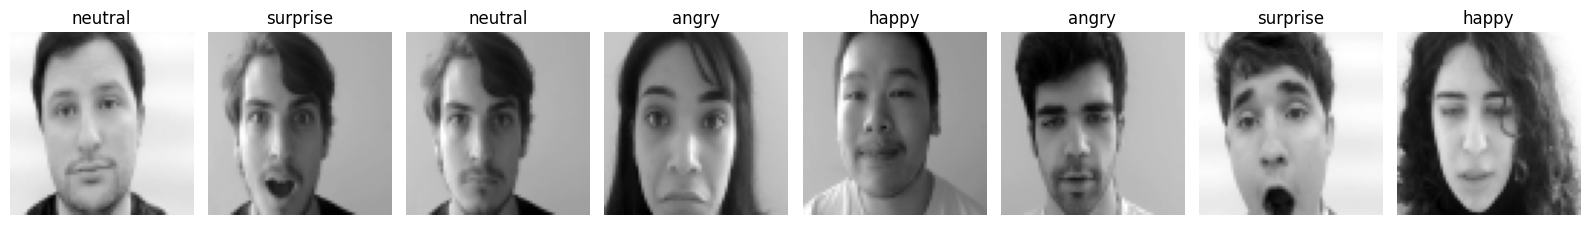

In [18]:
def show_sample_images(ds, class_names, n=8):
    for images, labels in ds.take(1):
        images = images[:n]
        labels = labels[:n]
        break

    plt.figure(figsize=(2 * n, 3))
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i].numpy().squeeze(), cmap="gray")
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_images(train_ds, class_names, n=8)

In [19]:
len(df)

5250

# Dataset Preparation – Private Emotion Dataset

In this section, the private dataset provided by the supervisor is prepared for training the emotion recognition models.

The dataset is organized into 21 subject folders (passage1 to passage21). Each folder contains facial images extracted from video sequences located in the directory:

emotion/frame/learning

Each image filename contains the emotion label. For example:

c0_0_1_surprised_212.png

From this filename, the emotion label "surprised" is extracted automatically.

Steps performed in this section:

1. Load images from all 21 passage folders.
2. Extract emotion labels from image filenames.
3. Construct a dataframe containing:
   - filepath
   - emotion label
   - subject identifier (passage)
4. Normalize labels (e.g., "surprised" → "surprise").
5. Encode emotion labels into numerical format.
6. Perform subject-independent dataset splitting:
   - 15 passages for training
   - 3 passages for validation
   - 3 passages for testing
7. Build TensorFlow datasets using tf.data for efficient training.

Images are resized to 64×64 grayscale and normalized to the range [0,1].

The resulting datasets are:

- train_ds
- val_ds
- test_ds

These datasets will be used to train and evaluate the Autoencoder (AE) and Variational Autoencoder (VAE) models.

# its new testing from resnet 18 and attention ways

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as tv_models

class EmotionVAE(nn.Module):
    def __init__(self, latent_dim=128, num_classes=5, input_channels=1):
        super(EmotionVAE, self).__init__()
        self.latent_dim = latent_dim

        # ==========================================
        # 1. ENCODER (ResNet-18 based)
        # ==========================================
        resnet = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
        resnet.conv1 = nn.Conv2d(input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.encoder_features = nn.Sequential(*list(resnet.children())[:-2])

        # Project to flat latent vector
        self.fc_mu = nn.Linear(512 * 2 * 2, latent_dim)
        self.fc_logvar = nn.Linear(512 * 2 * 2, latent_dim)

        # ==========================================
        # 2. MLP CLASSIFIER
        # ==========================================
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

        # ==========================================
        # 3. DECODER
        # ==========================================
        self.decoder_input = nn.Linear(latent_dim, 512 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, input_channels, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder_features(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        if self.training:
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std
        else:
            return mu

    def decode(self, z):
        x = self.decoder_input(z)
        x = x.view(x.size(0), 512, 4, 4)
        x = self.decoder(x)
        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        reconstruction = self.decode(z)
        class_logits = self.classifier(z)
        return reconstruction, mu, logvar, class_logits, z

In [ ]:
def vae_emotion_loss(reconstruction, original, mu, logvar, logits, labels,
                     kl_weight=0.001, cls_weight=1.0, recon_weight=0.6):

    # 1. Reconstruction Loss (Mean Squared Error)
    # Using sum reduction so it scales well with the image size
    recon_loss = F.mse_loss(reconstruction, original, reduction='sum') / original.size(0)

    # 2. KL Divergence Loss
    # Formula: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / original.size(0)

    # 3. Classification Loss (Cross Entropy for 5 classes)
    cls_loss = F.cross_entropy(logits, labels, reduction='mean')

    # Weighted total loss
    total_loss = (recon_weight * recon_loss) + (kl_weight * kl_loss) + (cls_weight * cls_loss)

    return total_loss, recon_loss, kl_loss, cls_loss

In [ ]:
# # Initialization
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = EmotionVAE(latent_dim=128, num_classes=5).to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# # Training Step
# model.train()
# for epoch in range(num_epochs):
#     for batch_idx, (images, labels) in enumerate(dataloader):
#         images, labels = images.to(device), labels.to(device)

#         # Forward pass
#         reconstruction, mu, logvar, logits, z = model(images)

#         # Calculate loss
#         total_loss, recon_loss, kl_loss, cls_loss = vae_emotion_loss(
#             reconstruction, images, mu, logvar, logits, labels,
#             kl_weight=0.005, cls_weight=5.0
#         )

#         # Backward pass
#         optimizer.zero_grad()
#         total_loss.backward()
#         optimizer.step()

#         if batch_idx % 50 == 0:
#             print(f"Epoch [{epoch}] | Total Loss: {total_loss.item():.4f} | "
#                   f"Recon: {recon_loss.item():.4f} | KL: {kl_loss.item():.4f} | "
#                   f"Cls: {cls_loss.item():.4f}")

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np

class EmotionPyTorchDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['filepath']
        label = self.df.iloc[idx]['label_id']

        # Load as Grayscale
        image = Image.open(img_path).convert('L')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# ============================================================
# UPDATED TRANSFORMS WITH DATA AUGMENTATION
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(), # Scales to [0, 1]
])

# Validation transform should NOT have random augmentation
val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Create DataLoaders
train_dataset_pt = EmotionPyTorchDataset(df_train, transform=train_transform)
val_dataset_pt = EmotionPyTorchDataset(df_val, transform=val_transform)

train_loader = DataLoader(train_dataset_pt, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset_pt, batch_size=32, shuffle=False)

print(f"PyTorch DataLoaders with Augmentation ready.")



PyTorch DataLoaders with Augmentation ready.


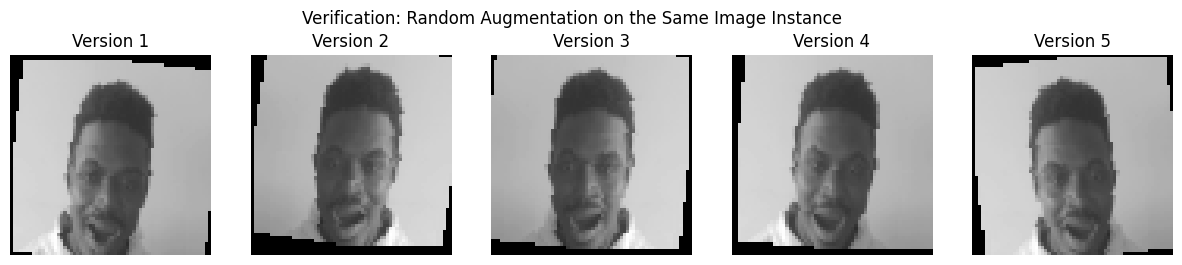

In [ ]:
import matplotlib.pyplot as plt

# Let's look at 5 different versions of the SAME image from the training loader
def check_augmentation_variance(dataset, index=0):
    plt.figure(figsize=(15, 3))
    for i in range(5):
        # Each time we call __getitem__, the random transforms are applied
        img, label = dataset[index]
        plt.subplot(1, 5, i + 1)
        plt.imshow(img.squeeze(), cmap='gray')
        plt.title(f"Version {i+1}")
        plt.axis('off')
    plt.suptitle("Verification: Random Augmentation on the Same Image Instance")
    plt.show()

check_augmentation_variance(train_dataset_pt, index=10)

In [ ]:
len(df)

5250

In [ ]:
len(train_dataset_pt)

3675

In [ ]:
# Initialization
num_epochs = 25
warmup_epochs = 5
import torchvision.models as tv_models
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Using standard flat 128-dim latent space
model = EmotionVAE(latent_dim=128, num_classes=5, input_channels=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

history = {
    'train_loss': [], 'train_recon': [], 'train_kl': [], 'train_cls': [], 'train_acc': [],
    'val_loss': [], 'val_recon': [], 'val_kl': [], 'val_cls': [], 'val_acc': []
}

print(f"Starting training on {device} with 128-dim latent space...")

for epoch in range(num_epochs):
    start_time = time.time()
    if epoch < warmup_epochs:
        for param in model.encoder_features.parameters(): param.requires_grad = False
        status = "[Warmup]"
    else:
        for param in model.encoder_features.parameters(): param.requires_grad = True
        status = "[Fine-tuning]"

    model.train()
    t_loss, t_recon, t_kl, t_cls, t_acc = 0, 0, 0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        reconstruction, mu, logvar, logits, z = model(images)
        loss, recon, kl, cls_l = vae_emotion_loss(
            reconstruction, images, mu, logvar, logits, labels,
            kl_weight=0.001, cls_weight=1.0, recon_weight=2.0
        )
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        t_loss += loss.item(); t_recon += recon.item(); t_kl += kl.item(); t_cls += cls_l.item()
        t_acc += (torch.argmax(logits, dim=1) == labels).sum().item()

    model.eval()
    v_loss, v_recon, v_kl, v_cls, v_acc = 0, 0, 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            reconstruction, mu, logvar, logits, z = model(images)
            loss, recon, kl, cls_l = vae_emotion_loss(
                reconstruction, images, mu, logvar, logits, labels,
                kl_weight=0.001, cls_weight=1.0, recon_weight=2.0
            )
            v_loss += loss.item(); v_recon += recon.item(); v_kl += kl.item(); v_cls += cls_l.item()
            v_acc += (torch.argmax(logits, dim=1) == labels).sum().item()

    n_train_batches, n_val_batches = len(train_loader), len(val_loader)
    cur_train_acc = t_acc / len(df_train)
    cur_val_acc = v_acc / len(df_val)

    # Store all metrics in history
    history['train_loss'].append(t_loss/n_train_batches)
    history['train_recon'].append(t_recon/n_train_batches)
    history['train_kl'].append(t_kl/n_train_batches)
    history['train_cls'].append(t_cls/n_train_batches)
    history['train_acc'].append(cur_train_acc)

    history['val_loss'].append(v_loss/n_val_batches)
    history['val_recon'].append(v_recon/n_val_batches)
    history['val_kl'].append(v_kl/n_val_batches)
    history['val_cls'].append(v_cls/n_val_batches)
    history['val_acc'].append(cur_val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} {status} - Train Acc: {cur_train_acc:.4f} - Val Acc: {cur_val_acc:.4f}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 372MB/s]


Starting training on cpu with 128-dim latent space...
Epoch 1/25 [Warmup] - Train Acc: 0.2005 - Val Acc: 0.2122
Epoch 2/25 [Warmup] - Train Acc: 0.2011 - Val Acc: 0.2186
Epoch 3/25 [Warmup] - Train Acc: 0.2071 - Val Acc: 0.2097
Epoch 4/25 [Warmup] - Train Acc: 0.1989 - Val Acc: 0.2186
Epoch 5/25 [Warmup] - Train Acc: 0.2005 - Val Acc: 0.2262
Epoch 6/25 [Fine-tuning] - Train Acc: 0.2103 - Val Acc: 0.1970
Epoch 7/25 [Fine-tuning] - Train Acc: 0.2046 - Val Acc: 0.1970
Epoch 8/25 [Fine-tuning] - Train Acc: 0.2093 - Val Acc: 0.2122


In [ ]:
import matplotlib.pyplot as plt

def plot_vae_history(history):
    epochs = range(1, len(history['train_loss']) + 1)
    plt.figure(figsize=(25, 5))

    # 1. Total Loss
    plt.subplot(1, 5, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Train')
    plt.plot(epochs, history['val_loss'], 'r--', label='Val')
    plt.title('Total Loss')
    plt.legend()

    # 2. Reconstruction Loss
    plt.subplot(1, 5, 2)
    plt.plot(epochs, history['train_recon'], 'g-', label='Train')
    plt.plot(epochs, history['val_recon'], 'y--', label='Val')
    plt.title('Recon Loss')
    plt.legend()

    # 3. KL Divergence Loss
    plt.subplot(1, 5, 3)
    plt.plot(epochs, history['train_kl'], 'c-', label='Train')
    plt.plot(epochs, history['val_kl'], 'm--', label='Val')
    plt.title('KL Loss')
    plt.legend()

    # 4. Classification Loss
    plt.subplot(1, 5, 4)
    plt.plot(epochs, history['train_cls'], 'm-', label='Train')
    plt.plot(epochs, history['val_cls'], 'k--', label='Val')
    plt.title('Classification Loss')
    plt.legend()

    # 5. Accuracy (Train vs Val)
    plt.subplot(1, 5, 5)
    plt.plot(epochs, history['train_acc'], 'b-o', label='Train')
    plt.plot(epochs, history['val_acc'], 'r-o', label='Val')
    plt.title('Classification Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
plot_vae_history(history)

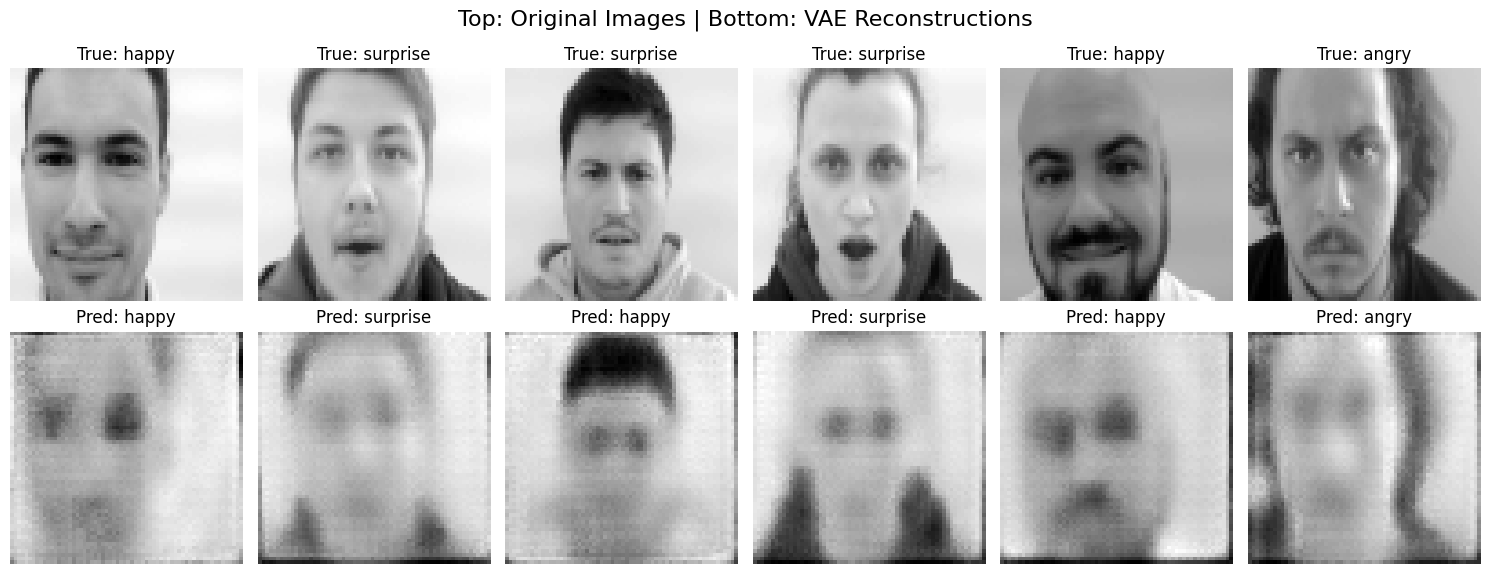

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_vae_reconstruction(model, dataloader, device, class_names, n=6):
    model.eval()
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        reconstruction, mu, logvar, logits, z = model(images)
        preds = torch.argmax(logits, dim=1)

    # Move to CPU for plotting
    images = images.cpu().numpy()
    reconstruction = reconstruction.cpu().numpy()
    labels = labels.cpu().numpy()
    preds = preds.cpu().numpy()

    plt.figure(figsize=(15, 6))
    for i in range(n):
        # Plot Original
        plt.subplot(2, n, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f"True: {class_names[labels[i]]}")
        plt.axis('off')

        # Plot Reconstruction
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstruction[i].squeeze(), cmap='gray')
        plt.title(f"Pred: {class_names[preds[i]]}")
        plt.axis('off')

    plt.suptitle("Top: Original Images | Bottom: VAE Reconstructions", fontsize=16)
    plt.tight_layout()
    plt.show()

# Run visualization
visualize_vae_reconstruction(model, val_loader, device, class_names, n=6)

# now its a new VAE 2

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [22]:
# import torch
# import torch.nn as nn

# class ConvBlock(nn.Module):
#     def __init__(self, in_channels, out_channels):
#         super().__init__()

#         self.block = nn.Sequential(
#             nn.Conv2d(in_channels, out_channels, 3, padding=1),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU(),

#             nn.Conv2d(out_channels, out_channels, 3, padding=1),
#             nn.BatchNorm2d(out_channels),
#             nn.ReLU()
#         )

#     def forward(self, x):
#         return self.block(x)

In [32]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels)
        )

        # Shortcut connection to handle channel dimension mismatch
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity() # If channels are the same, just pass through

    def forward(self, x):
        # Apply the convolutional block
        residual = self.conv(x)
        # Apply the shortcut connection
        shortcut_output = self.shortcut(x)
        # Add residual to shortcut output
        return torch.relu(shortcut_output + residual)

In [33]:
class Encoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()

        self.block1 = ResBlock(1, 32)     # 64×64
        self.pool1  = nn.MaxPool2d(2)      # → 32×32

        self.block2 = ResBlock(32, 64)    # 32×32
        self.pool2  = nn.MaxPool2d(2)      # → 16×16

        self.block3 = ResBlock(64, 128)   # 16×16
        self.pool3  = nn.MaxPool2d(2)      # → 8×8

        self.block4 = ResBlock(128, 256)  # 8×8
        self.pool4  = nn.MaxPool2d(2)      # → 4×4

        self.flatten = nn.Flatten()

        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)

    def forward(self, x):
        x = self.pool1(self.block1(x))
        x = self.pool2(self.block2(x))
        x = self.pool3(self.block3(x))
        x = self.pool4(self.block4(x))

        x = self.flatten(x)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

In [34]:
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [35]:
class Decoder(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()

        self.fc = nn.Linear(latent_dim, 128*8*8)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # 8 → 16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),   # 16 → 32
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, 2, 1),    # 32 → 64
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 128, 8, 8)
        x = self.deconv(x)
        return x

In [36]:
class Classifier(nn.Module):
    def __init__(self, latent_dim=64, num_classes=5):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )

    def forward(self, z):
        return self.net(z)

In [37]:
class VAE_Classifier(nn.Module):
    def __init__(self, latent_dim=64, num_classes=5):
        super().__init__()

        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)
        self.classifier = Classifier(latent_dim, num_classes)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)

        x_recon = self.decoder(z)
        logits = self.classifier(z)

        return x_recon, mu, logvar, logits

In [38]:
def loss_function(x, x_recon, mu, logvar, logits, labels, beta=1.0, gamma=5.0):

    # Reconstruction
    recon_loss = F.mse_loss(x_recon, x, reduction='mean')

    # KL Divergence
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    # Classification
    class_loss = F.cross_entropy(logits, labels)

    total_loss = 0.001*recon_loss + beta * kl_loss + gamma * class_loss

    return total_loss, recon_loss, kl_loss, class_loss

In [43]:
import torch
import torch.nn.functional as F # Added this import
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

class EmotionPyTorchDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]['filepath']
        label = self.df.iloc[idx]['label_id']

        image = Image.open(img_path).convert('L')

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

# Data transforms
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
])

# Create DataLoaders
train_loader = DataLoader(EmotionPyTorchDataset(df_train, transform=train_transform), batch_size=32, shuffle=True)
val_loader = DataLoader(EmotionPyTorchDataset(df_val, transform=val_transform), batch_size=32, shuffle=False)

def loss_function(x, x_recon, mu, logvar, logits, labels, beta=1.0, gamma=5.0):

    # Reconstruction
    recon_loss = F.mse_loss(x_recon, x, reduction='mean')

    # KL Divergence
    kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

    # Classification
    class_loss = F.cross_entropy(logits, labels)

    total_loss = 0.001*recon_loss + beta * kl_loss + gamma * class_loss

    return total_loss, recon_loss, kl_loss, class_loss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 25

model = VAE_Classifier(latent_dim=64, num_classes=5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(epochs):
    model.train()

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        x_recon, mu, logvar, logits = model(images)

        loss, recon, kl, cls = loss_function(
            images, x_recon, mu, logvar, logits, labels
        )

        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

Epoch 0 | Loss: 8.1590
Epoch 1 | Loss: 8.0540
Epoch 2 | Loss: 8.0833
Epoch 3 | Loss: 8.2042
Epoch 4 | Loss: 8.1934
Epoch 5 | Loss: 8.1305
Epoch 6 | Loss: 8.0720
Epoch 7 | Loss: 8.1790
Epoch 8 | Loss: 7.9408
Epoch 9 | Loss: 7.7393
Epoch 10 | Loss: 6.7904
Epoch 11 | Loss: 7.1531
Epoch 12 | Loss: 6.8862
Epoch 13 | Loss: 7.1342
Epoch 14 | Loss: 4.8528
Epoch 15 | Loss: 3.1718
Epoch 16 | Loss: 3.6823
Epoch 17 | Loss: 4.7698
Epoch 18 | Loss: 4.3594
Epoch 19 | Loss: 2.6927
Epoch 20 | Loss: 3.3894
Epoch 21 | Loss: 3.4682
Epoch 22 | Loss: 5.5182
Epoch 23 | Loss: 3.5753
Epoch 24 | Loss: 3.8406


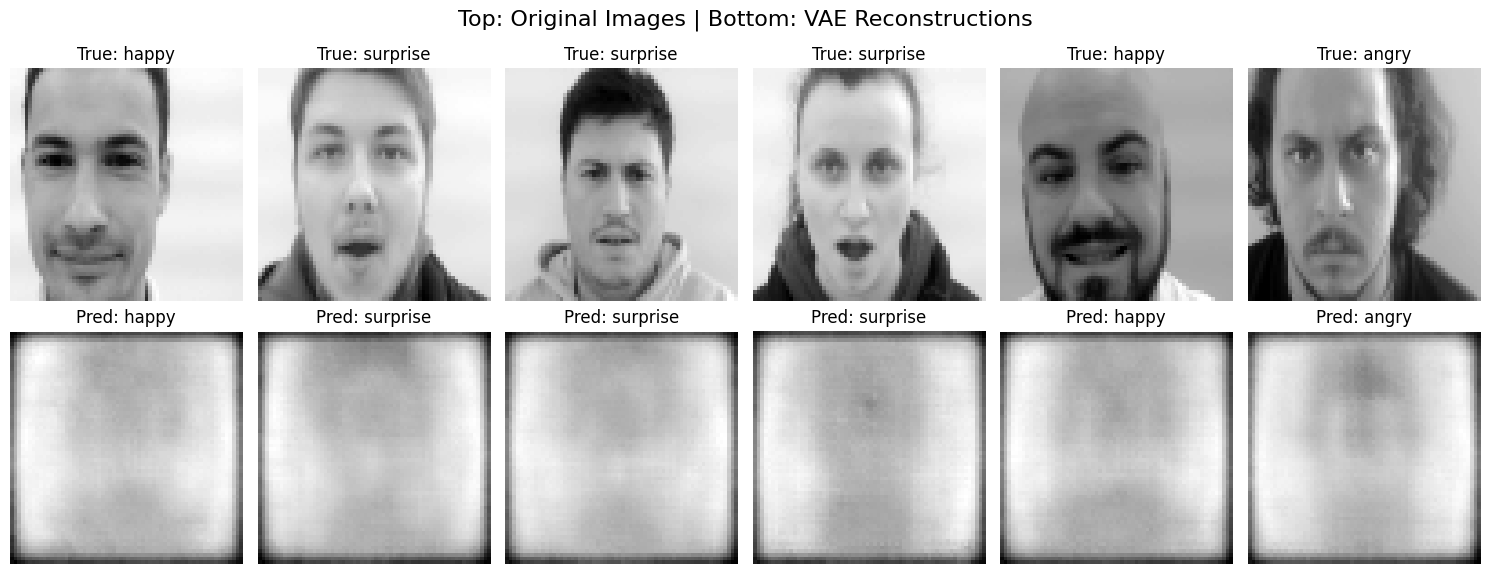

In [44]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_vae_reconstruction(model, dataloader, device, class_names, n=6):
    model.eval() # Set model to evaluation mode

    # Get a batch of images and labels
    images, labels = next(iter(dataloader))
    images, labels = images.to(device), labels.to(device)

    with torch.no_grad():
        x_recon, mu, logvar, logits = model(images)
        preds = torch.argmax(logits, dim=1)

    # Move to CPU for plotting
    images = images.cpu().numpy()
    x_recon = x_recon.cpu().numpy()
    labels = labels.cpu().numpy()
    preds = preds.cpu().numpy()

    plt.figure(figsize=(15, 6))
    for i in range(n):
        # Plot Original
        plt.subplot(2, n, i + 1)
        plt.imshow(images[i].squeeze(), cmap='gray')
        plt.title(f"True: {class_names[labels[i]]}")
        plt.axis('off')

        # Plot Reconstruction
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(x_recon[i].squeeze(), cmap='gray')
        plt.title(f"Pred: {class_names[preds[i]]}")
        plt.axis('off')

    plt.suptitle("Top: Original Images | Bottom: VAE Reconstructions", fontsize=16)
    plt.tight_layout()
    plt.show()

# Visualize reconstructions using the trained VAE_Classifier
# Assuming `val_loader` and `class_names` are defined from previous steps
visualize_vae_reconstruction(model, val_loader, device, class_names, n=6)